# [4.0] DESI x DESI Legacy Crossmatch

In this notebook, we will:
- **crossmatch** the DESI Main Survey (dark program) DR1 with the DESI Legacy survey hosted on [data.lsdb.io](data.lsdb.io)
- **save** the resulting catalog to the NERSC Community File System (CFS)
- discuss **performance and resource use** of the crossmatch

## Set up

In [1]:
import os
import time
from pathlib import Path

import lsdb
import matplotlib.pyplot as plt
import pandas as pd
from dask.distributed import Client, performance_report
from hats.io.validation import is_valid_catalog


# Set our output directory

users_dir = Path("/global/cfs/cdirs/cosmo/users/")
target_user_dir = users_dir / "olynn"

In [2]:
# Make a dask client

client = Client(
    n_workers=32,
    threads_per_worker=2,
    memory_limit="14GB",   # 32 × 14 = 448 GB, well within 487 GB
)

In [3]:
# Set up dashboard port forwarding instructions for the user. 
# Note that the compute node hostname is needed to set up the ssh tunnel correctly.

import socket

username = os.getenv("USER")
current_compute_node = socket.gethostname()

print(f"1. In a local shell, run: ssh -L 8787:{current_compute_node}:8787 {username}@perlmutter.nersc.gov")
print("2. Enter password + OTP")
print(f"3. See Dask Dashboard in browser (on your local machine) at: http://localhost:8787/status")

1. In a local shell, run: ssh -L 8787:nid004198:8787 olynn@perlmutter.nersc.gov
2. Enter password + OTP
3. See Dask Dashboard in browser (on your local machine) at: http://localhost:8787/status


## Load catalogs

In [4]:
desi_cat = lsdb.open_catalog("/global/cfs/cdirs/cosmo/users/olynn/desi-dr1-main-dark")
desi_cat

,TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,spectra_b,spectra_r,spectra_z
npartitions=5769,,,,,,,,
"Order: 6, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv..."
"Order: 6, Pixel: 1",...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12286",...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12287",...,...,...,...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of desi-dr1-main-dark'}>)

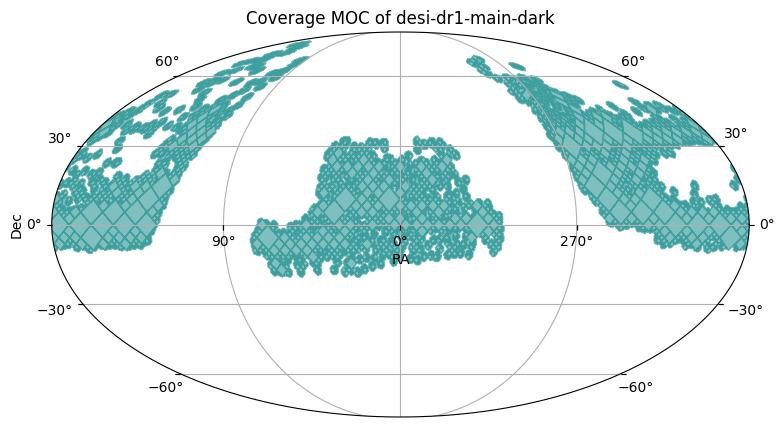

In [5]:
desi_cat.plot_coverage()

In [6]:
desi_legacy_cat = lsdb.open_catalog(
    "https://data.lsdb.io/hats/legacysurvey_dr10.1",
    #columns=["source_id", "ra", "dec"]
)
desi_legacy_cat

,RELEASE,BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,RA_IVAR,DEC_IVAR,DCHISQ,EBV,FLUX_G,FLUX_R,FLUX_I,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_W3,FLUX_W4,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_I,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FLUX_IVAR_W3,FLUX_IVAR_W4,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_I,MW_TRANSMISSION_Z,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,MW_TRANSMISSION_W3,MW_TRANSMISSION_W4,NOBS_G,NOBS_R,NOBS_I,NOBS_Z,NOBS_W1,NOBS_W2,NOBS_W3,NOBS_W4,RCHISQ_G,RCHISQ_R,RCHISQ_I,RCHISQ_Z,RCHISQ_W1,RCHISQ_W2,RCHISQ_W3,RCHISQ_W4,FRACFLUX_G,FRACFLUX_R,FRACFLUX_I,FRACFLUX_Z,FRACFLUX_W1,FRACFLUX_W2,FRACFLUX_W3,FRACFLUX_W4,FRACMASKED_G,FRACMASKED_R,FRACMASKED_I,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_I,FRACIN_Z,ANYMASK_G,ANYMASK_R,ANYMASK_I,ANYMASK_Z,ALLMASK_G,ALLMASK_R,ALLMASK_I,ALLMASK_Z,WISEMASK_W1,WISEMASK_W2,PSFSIZE_G,PSFSIZE_R,PSFSIZE_I,PSFSIZE_Z,PSFDEPTH_G,PSFDEPTH_R,PSFDEPTH_I,PSFDEPTH_Z,GALDEPTH_G,GALDEPTH_R,GALDEPTH_I,GALDEPTH_Z,PSFDEPTH_W1,PSFDEPTH_W2,WISE_COADD_ID,SHAPE_R,SHAPE_R_IVAR,SHAPE_E1,SHAPE_E1_IVAR,SHAPE_E2,SHAPE_E2_IVAR,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_I,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_I,FIBERTOTFLUX_Z,REF_CAT,REF_ID,REF_EPOCH,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_G_MEAN_FLUX_OVER_ERROR,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_BP_MEAN_FLUX_OVER_ERROR,GAIA_PHOT_RP_MEAN_MAG,GAIA_PHOT_RP_MEAN_FLUX_OVER_ERROR,GAIA_ASTROMETRIC_EXCESS_NOISE,GAIA_DUPLICATED_SOURCE,GAIA_PHOT_BP_RP_EXCESS_FACTOR,GAIA_ASTROMETRIC_SIGMA5D_MAX,GAIA_ASTROMETRIC_PARAMS_SOLVED,PARALLAX,PARALLAX_IVAR,PMRA,PMRA_IVAR,PMDEC,PMDEC_IVAR,MASKBITS,FITBITS,SERSIC,SERSIC_IVAR
npartitions=64179,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Order: 6, Pixel: 0",int16[pyarrow],int32[pyarrow],string[pyarrow],int32[pyarrow],string[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],fixed_size_list<element: float>[5][pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],uint8[pyarrow],uint8[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],string[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],string[pyarrow],int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],bool[pyarrow],float[pyarrow],float[pyarrow],uint8[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int32[pyarrow],int16[pyarrow],float[pyarrow],float[pyarrow]
"Order: 6, Pixel: 1",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of legacysurvey_dr10.1'}>)

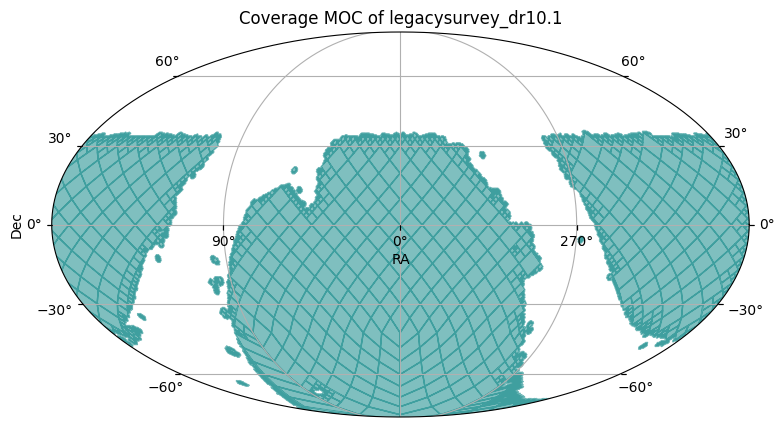

In [7]:
desi_legacy_cat.plot_coverage()

## Do crossmatch

In [8]:
desi_dr1_x_desi_legacy = desi_cat.crossmatch(desi_legacy_cat, suffix_method="overlapping_columns", suffixes=("_dr1", "_legacy"))

In [9]:
start = time.perf_counter()

catalog_name = "desi_dr1_x_desi_legacy"
with performance_report(filename="crossmatch_report.html"):
    desi_dr1_x_desi_legacy.write_catalog(
        base_catalog_path=target_user_dir,
        catalog_name=catalog_name,
    )

elapsed = time.perf_counter() - start

/global/homes/o/olynn/.venvs/p312/lib/python3.12/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 31.51 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/global/homes/o/olynn/.venvs/p312/lib/python3.12/site-packages/lsdb/dask/merge_catalog_functions.py:232: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  joined_df = pd.concat([partition, margin])
/global/homes/o/olynn/.venvs/p312/lib/python3.12/site-packages/lsdb/dask/merge_catalog_functions.py:232: FutureWarning: The behavior of array concatenation wi

In [10]:
print(f"Crossmatch took {int(elapsed/60):d}m {elapsed%60:.1f}s")

Crossmatch took 51m 8.3s


In case I end up removing the cell output above, I'm recording it for posterity:

```bash
/global/homes/o/olynn/.venvs/p312/lib/python3.12/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 31.51 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/global/homes/o/olynn/.venvs/p312/lib/python3.12/site-packages/lsdb/dask/merge_catalog_functions.py:232: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  joined_df = pd.concat([partition, margin])
/global/homes/o/olynn/.venvs/p312/lib/python3.12/site-packages/lsdb/dask/merge_catalog_functions.py:232: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  joined_df = pd.concat([partition, margin])
  ```

## Verify crossmatched catalog

In [11]:
# Check that the catalog was written correctly

output_catalog = target_user_dir / catalog_name

is_valid_catalog(output_catalog, verbose=True, fail_fast=False, strict=True)

Validating catalog at path /global/cfs/cdirs/cosmo/users/olynn/desi_dr1_x_desi_legacy ... 
Found 19221 partitions.
Approximate coverage is 21.77 % of the sky.


True

In [12]:
# Calculate size of the catalog on disk

! du -sh $output_catalog

/global/common/software/nersc/pe/conda-envs/26.1.0/python-3.12/nersc-python/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=1690611) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


561G	/global/cfs/cdirs/cosmo/users/olynn/desi_dr1_x_desi_legacy


In [13]:
# Open catalog

desi_dr1_x_desi_legacy_cat = lsdb.open_catalog(output_catalog)
desi_dr1_x_desi_legacy_cat

,TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,spectra_b,spectra_r,spectra_z,RELEASE,BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,RA_IVAR,DEC_IVAR,DCHISQ,EBV,FLUX_G,FLUX_R,FLUX_I,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_W3,FLUX_W4,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_I,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FLUX_IVAR_W3,FLUX_IVAR_W4,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_I,MW_TRANSMISSION_Z,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,MW_TRANSMISSION_W3,MW_TRANSMISSION_W4,NOBS_G,NOBS_R,NOBS_I,NOBS_Z,NOBS_W1,NOBS_W2,NOBS_W3,NOBS_W4,RCHISQ_G,RCHISQ_R,RCHISQ_I,RCHISQ_Z,RCHISQ_W1,RCHISQ_W2,RCHISQ_W3,RCHISQ_W4,FRACFLUX_G,FRACFLUX_R,FRACFLUX_I,FRACFLUX_Z,FRACFLUX_W1,FRACFLUX_W2,FRACFLUX_W3,FRACFLUX_W4,FRACMASKED_G,FRACMASKED_R,FRACMASKED_I,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_I,FRACIN_Z,ANYMASK_G,ANYMASK_R,ANYMASK_I,ANYMASK_Z,ALLMASK_G,ALLMASK_R,ALLMASK_I,ALLMASK_Z,WISEMASK_W1,WISEMASK_W2,PSFSIZE_G,PSFSIZE_R,PSFSIZE_I,PSFSIZE_Z,PSFDEPTH_G,PSFDEPTH_R,PSFDEPTH_I,PSFDEPTH_Z,GALDEPTH_G,GALDEPTH_R,GALDEPTH_I,GALDEPTH_Z,PSFDEPTH_W1,PSFDEPTH_W2,WISE_COADD_ID,SHAPE_R,SHAPE_R_IVAR,SHAPE_E1,SHAPE_E1_IVAR,SHAPE_E2,SHAPE_E2_IVAR,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_I,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_I,FIBERTOTFLUX_Z,REF_CAT,REF_ID,REF_EPOCH,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_G_MEAN_FLUX_OVER_ERROR,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_BP_MEAN_FLUX_OVER_ERROR,GAIA_PHOT_RP_MEAN_MAG,GAIA_PHOT_RP_MEAN_FLUX_OVER_ERROR,GAIA_ASTROMETRIC_EXCESS_NOISE,GAIA_DUPLICATED_SOURCE,GAIA_PHOT_BP_RP_EXCESS_FACTOR,GAIA_ASTROMETRIC_SIGMA5D_MAX,GAIA_ASTROMETRIC_PARAMS_SOLVED,PARALLAX,PARALLAX_IVAR,PMRA,PMRA_IVAR,PMDEC,PMDEC_IVAR,MASKBITS,FITBITS,SERSIC,SERSIC_IVAR,_dist_arcsec
npartitions=19221,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Order: 6, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...",int16[pyarrow],int32[pyarrow],string[pyarrow],int32[pyarrow],string[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],fixed_size_list<element: float>[5][pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],uint8[pyarrow],uint8[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],string[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],string[pyarrow],int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],bool[pyarrow],float[pyarrow],float[pyarrow],uint8[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int32[pyarrow],i

(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of desi_dr1_x_desi_legacy'}>)

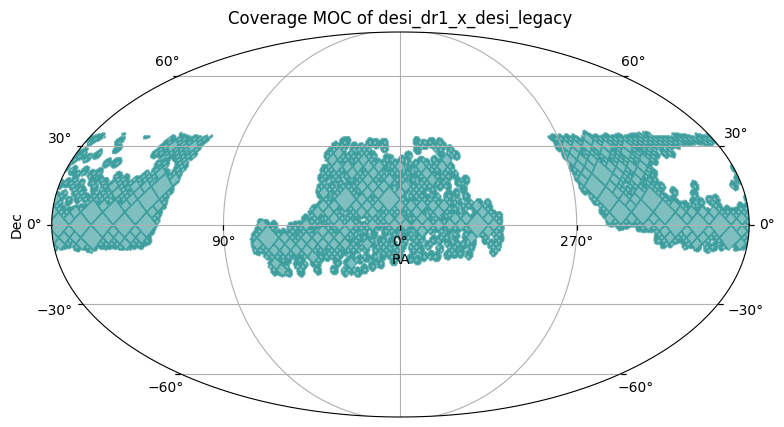

In [14]:
# Plot coverage

desi_dr1_x_desi_legacy_cat.plot_coverage()

In [15]:
# See the first few rows

df = desi_dr1_x_desi_legacy_cat.head(5)
df

TARGETID  TARGET_RA  TARGET_DEC         Z      ZERR  \
_healpix_29                                                                  
24531778214   39627785483846048  45.014136    0.019739  1.308415  0.000399   
76347715933   39627785483846390  45.027565    0.029181  0.884491  0.000116   
79430617729    2714981116149760  45.018964    0.029766  0.129609  0.000009   
101138674798  39627785483846478  45.030526    0.041094  1.263249   0.00009   
137832201964  39627785479657462  44.980268    0.021299  1.301057  0.000109   

                                                      spectra_b  \
_healpix_29                                                       
24531778214   [{wavelength: 3600.0, flux: 2.924896, ivar: 0....   
76347715933   [{wavelength: 3600.0, flux: -3.560856, ivar: 0...   
79430617729   [{wavelength: 3600.0, flux: -5.12881, ivar: 0....   
101138674798  [{wavelength: 3600.0, flux: 0.314766, ivar: 0....   
137832201964  [{wavelength: 3600.0, flux: 1.310825, ivar: 0....   

                                                      spectra_r  \
_healpix_29                                                       
24531778214   [{wavelength: 5760.0, flux: 1.965631, ivar: 7....   
76347715933   [{wavelength: 5760.0, flux: 0.741585, ivar: 0....   
79430617729   [{wavelength: 5760.0, flux: 0.757192, ivar: 0....   
101138674798  [{wavelength: 5760.0, flux: 0.615158, ivar: 3....   
137832201964  [{wavelength: 5760.0, flux: 0.470588, ivar: 4....   

                                                      spectra_z  RELEASE  \
_healpix_29                                                                
24531778214   [{wavelength: 7520.0, flux: 0.379682, ivar: 23...    10000   
76347715933   [{wavelength: 7520.0, flux: -0.305626, ivar: 5...    10000   
79430617729   [{wavelength: 7520.0, flux: 0.227893, ivar: 10...    10000   
101138674798  [{wavelength: 7520.0, flux: 1.088948, ivar: 11...    10000   
137832201964  [{wavelength: 7520.0, flux: 0.220877, ivar: 19...    10000   

              BRICKID  ... PARALLAX_IVAR  PMRA PMRA_IVAR  PMDEC  PMDEC_IVAR  \
_healpix_29            ...                                                    
24531778214    330548  ...           0.0   0.0       0.0    0.0         0.0   
76347715933    330548  ...           0.0   0.0       0.0    0.0         0.0   
79430617729    330548  ...           0.0   0.0       0.0    0.0         0.0   
101138674798   330548  ...           0.0   0.0       0.0    0.0         0.0   
137832201964   330547  ...           0.0   0.0       0.0    0.0         0.0   

              MASKBITS  FITBITS    SERSIC  SERSIC_IVAR  _dist_arcsec  
_healpix_29                                                           
24531778214          0        0       0.0          0.0      0.001237  
76347715933          0        0       1.0          0.0      0.004593  
79430617729          0        0  0.695048   742.435547      0.003547  
101138674798         0        0       1.0          0.0      0.005384  
137832201964         0        0       0.0          0.0      0.010109  

[5 rows x 139 columns]

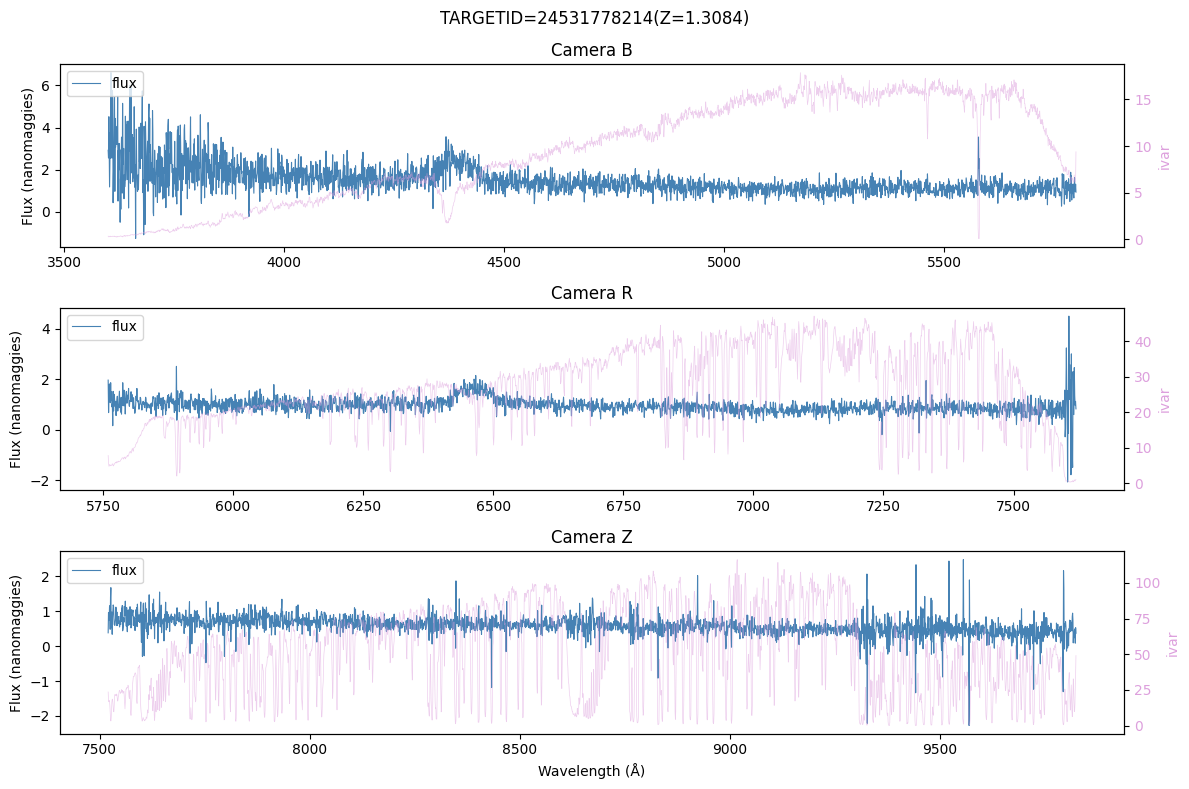

In [22]:
# Plot spectra of a row

target_idx = 0

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
colors = ["steelblue", "plum"]

# Iterate over the three cameras and plot the spectra for the target at target_idx.
for ax, cam in zip(axes, ["b", "r", "z"]):
    # Get the spectrum.
    spec = df[f"spectra_{cam}"].iloc[target_idx]

    # Plot flux on the primary y-axis.
    ax.plot(spec["wavelength"], spec["flux"], lw=0.8, color=colors[0], label="flux")
    
    # Plot ivar on the secondary y-axis.
    ax_twin = ax.twinx()
    ax_twin.plot(spec["wavelength"], spec["ivar"], lw=0.5, color=colors[1], alpha=0.5, label="ivar")
    ax_twin.set_ylabel("ivar", color=colors[1])
    ax_twin.tick_params(axis="y", labelcolor=colors[1])
    
    # Set labels and title for the primary y-axis.
    ax.set_ylabel("Flux (nanomaggies)") # https://desidatamodel.readthedocs.io/en/latest/DESI_SPECTRO_DATA/NIGHT/EXPID/fibermap-EXPID.html#required-data-table-columns:~:text=nanomaggies
    ax.set_title(f"Camera {cam.upper()}")
    ax.legend(loc="upper left")

# Set x-axis label and overall figure title.
axes[-1].set_xlabel("Wavelength (Å)")
fig.suptitle(f"TARGETID={df.index[target_idx]}(Z={df['Z'].iloc[target_idx]:.4f})")
plt.tight_layout()
plt.show()

## Performance Analysis

In [23]:
# Generate markdown tables for the Dask dashboard reports

from dask_report_utils import client_table, metrics_table

print(client_table("crossmatch_report.html", threads_per_worker=2, memory_limit_per_worker="14 GB"), "\n")
print(metrics_table("crossmatch_report.html"), "\n")

| Parameter | Value |
|---|---|
| Workers | 32 |
| Threads per worker | 2 |
| Total threads | 64 |
| Memory per worker | 14 GB |
| Total memory | 417.23 GiB | 

| Metric | Value |
|---|---|
| Total tasks | 100000 |
| Wall time | 51m 4s |
| Compute time (all workers) | 19hr 30m |
| Transfer time | 90m 24s |
| Disk read time | N/A |
| Disk write time | 10m 45s |
| Total bandwidth | N/A | 



### 1. Setup

The crossmatch was run on a Perlmutter CPU node at NERSC using a local Dask distributed 
client. 

The full DESI DR1 Main Survey (Dark Program), stored on the NERSC Community File System 
(CFS), was crossmatched against the full DESI Legacy Survey DR10.1 catalog, accessed
remotely from the LSDB public data server (`https://data.lsdb.io/hats/legacysurvey_dr10.1`).

The Dask client was configured as follows:


| Parameter | Value |
|---|---|
| Workers | 32 |
| Threads per worker | 2 |
| Total threads | 64 |
| Memory per worker | 14 GB |
| Total memory | 417.23 GiB | 

### 2. Wall Time

The full crossmatch — from the `desi.crossmatch(legacy).compute()` call to completion —
took **3068.3 seconds** (~51m 8s) as measured by `time.perf_counter()`.

This reflects total wall time on a single Perlmutter CPU node, including task graph
construction, data reads from both the local CFS (DESI) and remote LSDB server (Legacy
Survey), and the crossmatch computation itself. Sub-step timing was not recorded
separately; the Dask performance report in section 3 provides a finer-grained breakdown
of where time was spent.

### 3. Dask Performance Report

<div class="alert alert-warning">
<b>⚠︎ Large Task Graph</b>
During execution, Dask raised the following warning:
<pre><samp>
/.../site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 31.51 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
</samp></pre>
</div>

The Dask performance report recorded a wall time of **51m 4s** across **100,000 tasks**,
consistent with the `perf_counter` measurement. Key metrics from the report summary are
as follows:

| Metric | Value |
|---|---|
| Total tasks | 100,000 |
| Wall time | 51m 4s |
| Compute time (all workers) | 19hr 30m |
| Transfer time | 90m 24s |
| Disk read time | N/A |
| Disk write time | 10m 45s |
| Total bandwidth | N/A |

The aggregate compute time of **19hr 30m** distributed across 32 workers yields an average
of ~36.5 minutes per worker, compared to a wall time of 51m 4s. This is reasonable but
suggests somewhat less uniform worker utilization than the DESI x Gaia crossmatch, where
the per-worker average closely matched the wall time.

The most striking figure is the **transfer time of 90m 24s**, which dwarfs the 15m 13s
seen in the Gaia crossmatch. This likely reflects the increased overhead of accessing the
Legacy Survey catalog over HTTPS from `data.lsdb.io`, compared to the S3-optimized access
used for Gaia. The large task graph warning is also relevant here — a 31.51 MiB graph
being serialized and sent to workers adds overhead that would compound with an already
costly data transfer, and may partially account for both the elevated transfer time and
the longer wall time relative to the Gaia crossmatch.

Disk read time was not reported, which is consistent with data being streamed directly
into worker memory rather than spilling to disk. Disk write time of **10m 45s** is
modest relative to the overall wall time, which is expected — the bulk of the 51 minutes
was spent on computation and data transfer, with the catalog write being a comparatively
cheap one-time operation at the end. As noted in the DESI x Gaia crossmatch, this figure
may not fully capture the `write_catalog()` output to CFS, since Dask may not register
writes to a network-mounted filesystem as local disk I/O. Total bandwidth was not
reported by this version of the performance report.